# Research Question 3: Spatial Distribution of Reports in 2025
<div style="background-color:#f0f4f8; padding:15px; border-left:6px solid #2f5597; border-radius:6px;">

## Research Question

Which Zurich Quartiere had the highest reporting intensity of ZüriWieNeu reports per resident in 2025?

## Goal of this notebook

The goal of this notebook is to analyse the spatial distribution of ZüriWieNeu reports across Zurich's Quartiere for the year 2025 as a **normalised rate**, namely the number of reports per 1,000 residents.

While the first two research questions focused on temporal changes and category composition, this notebook adds a spatial perspective. Individual reports are point-based observations, meaning that each report has a specific location. By connecting these point locations to neighborhood polygons, reports can be aggregated to the Quartier level and compared between neighbourhoods.

A first look at the raw counts per Quartier is shown as a reference, but the main result is a **choropleth map of reports per 1,000 residents**. A proper choropleth map shows a *rate* or *share* rather than absolute counts, because counts on a polygon map are strongly driven by how many people live in each polygon. Without normalisation, large or populous Quartiere will almost always appear darker, and the map mostly recovers the underlying population pattern rather than telling us anything about reporting behaviour.

## Why this question is relevant

Comparing reporting activity across neighbourhoods only makes sense once differences in population size are accounted for. A Quartier with 20,000 residents and 1,000 reports is reporting at a very different intensity than a Quartier with 5,000 residents and the same 1,000 reports, even though the absolute counts are identical. The rate of reports per 1,000 residents captures this difference.

However, the rate should still be interpreted carefully. ZüriWieNeu reports are not only generated by residents but also by people who pass through a Quartier — commuters, shoppers, nightlife visitors, tourists. Dividing by residential population therefore tends to **inflate the rate** in central, visitor-heavy Quartiere such as those around Langstrasse, where many reports are generated by non-residents but only residents appear in the denominator. The rate is more informative than raw counts, but it does not fully control for visitor or commuter activity.

## Planned analysis

In this notebook, I will:

1. Load and clean the ZüriWieNeu report data.
2. Filter the reports to the year 2025.
3. Convert the report coordinates into a GeoDataFrame.
4. Load the Zurich Quartiere polygon shapefile.
5. Perform a spatial join between reports and Quartiere.
6. Count the number of reports per Quartier (as a first reference).
7. Load population data per Quartier from Open Data Zürich.
8. Compute reports per 1,000 residents per Quartier.
9. Compute the area of the Quartiere
10. Visualise the result as a choropleth map - based on reports per residents.
11. Visualise the result as a choropleth map - based on the km2 size of the Quartier
12. Interpret the spatial pattern of reporting intensity.


In [21]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from src.loading import load_csv_data
from src.cleaning import clean_reports
from src.spatial import reports_to_geodataframe, join_reports_to_quartiere

**ZüriWieNeu reports data**

In [8]:
# loading and cleaning the report data
df_raw = load_csv_data("../data/raw/stzh.zwn_meldungen_p.csv")
df_cleaned = clean_reports(df_raw)

/Users/laumagoldmann/Desktop/SDS210_IndividualProject/src/cleaning.py:111: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


In [20]:
# create a DataFrame only containing the reports from the year 2025
df_2025 = df_cleaned[df_cleaned["year"] == 2025].copy()

# transform the reports to a GeoDataFrame
reports_2025_gdf = reports_to_geodataframe(df_2025)

# investigate the GeoDataFrame data
print("The first few rows of the gdf are: ")
display(reports_2025_gdf.head())

print("The columns of the gdf are:")
display(reports_2025_gdf.columns)

print("The coordinate system of the gdf is:")
display(reports_2025_gdf.crs)

The first few rows of the gdf are: 


,objectid,service_request_id,requested_datetime,agency_sent_datetime,updated_datetime,e,n,service_code,service_name,status,...,detail,media_url,interface_used,service_notice,description,url,geometry,year,month,year_month
44670,62831,70201,2025-06-16 20:06:53+00:00,2025-06-17 07:07:04+00:00,2025-06-17 07:07:04+00:00,2682447,1247655,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Veloschrott,https://www.zueriwieneu.ch/photo/70201.0.jpeg?...,desktop,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Veloschrott: Veloschrott,https://www.zueriwieneu.ch/report/70201,POINT (2682447 1247655),2025,6,2025-06-01
45845,61418,68672,2025-05-12 10:05:31+00:00,2025-05-12 10:12:05+00:00,2025-05-12 10:12:05+00:00,2681227,1248047,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Demoliertes Velo,https://www.zueriwieneu.ch/photo/68672.0.jpeg?...,Android,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Demoliertes: Demoliertes Velo,https://www.zueriwieneu.ch/report/68672,POINT (2681227 1248047),2025,5,2025-05-01
45867,61844,69139,2025-05-22 19:41:18+00:00,2025-05-22 19:42:05+00:00,2025-05-26 05:42:43+00:00,2682870,1247836,Beleuchtung/Uhren,Beleuchtung/Uhren,fixed - council,...,Lampe kaputt,NaN,iOS,Besten Dank für Ihre Meldung auf «Züri wie neu...,Lampe kaput: Lampe kaputt,https://www.zueriwieneu.ch/report/69139,POINT (2682870 1247836),2025,5,2025-05-01
45975,63320,70728,2025-06-29 18:24:09+00:00,2025-06-30 12:12:04+00:00,2025-06-30 12:12:04+00:00,2681519,1247334,Abfall/Sammelstelle,Abfall/Sammelstelle,external,...,Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/photo/70728.0.jpeg?...,iOS,Freundliche Grüsse <br/> <br/> Ihre Stadt Zür...,Ausgeschlac: Ausgeschlachteter Scooter,https://www.zueriwieneu.ch/report/70728,POINT (2681519 1247334),2025,6,2025-06-01
46705,58911,65900,2025-02-16 22:19:45+00:00,2025-03-31 09:57:05+00:00,2025-04-03 10:26:13+00:00,2683763,1247000,Graffiti,Graffiti,fixed - council,...,Graffiti,NaN,Android,Besten Dank für Ihre Meldung auf «Züri wie neu...,Graffiti: Graffiti,https://www.zueriwieneu.ch/report/65900,POINT (2683763 1247000),2025,2,2025-02-01


The columns of the gdf are:


Index(['objectid', 'service_request_id', 'requested_datetime',
       'agency_sent_datetime', 'updated_datetime', 'e', 'n', 'service_code',
       'service_name', 'status', 'userid', 'title', 'detail', 'media_url',
       'interface_used', 'service_notice', 'description', 'url', 'geometry',
       'year', 'month', 'year_month'],
      dtype='str')

The coordinate system of the gdf is:


<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

**Quartier Data**

In [14]:
# load the quartier data for plotting the data
quartiere_zh = gpd.read_file("../data/raw/StatQuartiere_ZH")

/Users/laumagoldmann/miniconda3/envs/sds-env/lib/python3.14/site-packages/pyogrio/geopandas.py:275: UserWarning: More than one layer found in 'StatQuartiere_ZH': 'stzh.adm_statistische_quartiere_v' (default), 'stzh.adm_statistische_quartiere_b_p', 'stzh.adm_statistische_quartiere_map'. Specify layer parameter to avoid this warning.
  result = read_func(


In [17]:
# investigate the quartier data
print("The first few rows of the quartier data are: ")
display(quartiere_zh.head())

print("The columns of the quartier data are:")
display(quartiere_zh.columns)

print("The coordinate system of the quartier data is:")
display(quartiere_zh.crs)

The first few rows of the quartier data are: 


,objid,objectid,qname,qnr,kname,knr,geometry
0,1,1,Alt-Wiedikon,31,Kreis 3,3,"POLYGON ((2680606.662 1247034.584, 2680626.356..."
1,10,2,Witikon,74,Kreis 7,7,"POLYGON ((2685858.632 1246502.629, 2685860.738..."
2,11,3,Langstrasse,42,Kreis 4,4,"POLYGON ((2681313.304 1248613.857, 2681459.605..."
3,12,4,Escher Wyss,52,Kreis 5,5,"POLYGON ((2680009.144 1249565.021, 2680055.843..."
4,13,5,Enge,24,Kreis 2,2,"POLYGON ((2681898.171 1246379.668, 2681899.115..."


The columns of the quartier data are:


Index(['objid', 'objectid', 'qname', 'qnr', 'kname', 'knr', 'geometry'], dtype='str')

The coordinate system of the quartier data is:


<Projected CRS: EPSG:2056>
Name: CH1903+ / LV95
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Liechtenstein; Switzerland.
- bounds: (5.95, 45.81, 10.5, 47.81)
Coordinate Operation:
- name: Swiss Oblique Mercator 1995
- method: Hotine Oblique Mercator (variant B)
Datum: CH1903+
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

**Spatial join of report data to Quartiere in the City of Zurich**

In [24]:
# join the reports to the quartiere through the "join_reports_to_quartiere" function
reports_2025_joined = join_reports_to_quartiere(reports_2025_gdf, quartiere_zh)

# display the relevant columns of the new DataFrame
reports_2025_joined[["service_request_id", "qname", "qnr", "kname", "knr"]].head()

,service_request_id,qname,qnr,kname,knr
44670,70201,Langstrasse,42,Kreis 4,4
45845,68672,Hard,44,Kreis 4,4
45867,69139,City,14,Kreis 1,1
45975,70728,Sihlfeld,34,Kreis 3,3
46705,65900,Hochschulen,12,Kreis 1,1


In [25]:
# command to check if all reports have been matched to a Quartier (expected value should be zero)
reports_2025_joined["qname"].isna().sum()

np.int64(0)

The spatial join successfully assigned all 2025 reports to a Zurich Quartier. No reports had missing Quartier information after the join.

In [26]:
# sort the Quartiers by the amount of report counts
reports_by_quartier = (
    reports_2025_joined
    .groupby("qname")
    .size()
    .reset_index(name="report_count")
    .sort_values("report_count", ascending=False)
)

# display the first 10 Quartiere of the City of Zurich
reports_by_quartier.head(10)


,qname,report_count
16,Langstrasse,1200
27,Sihlfeld,795
3,Altstetten,628
31,Wipkingen,528
28,Unterstrass,517
10,Hard,470
25,Seebach,464
2,Alt-Wiedikon,456
21,Oerlikon,453
15,Höngg,417


## A first look: report counts per Quartier

The table above shows the ten Zurich Quartiere with the highest absolute number of ZüriWieNeu reports in 2025. This is useful as a starting point, but absolute counts do not yet form a proper choropleth: large differences in population size between Quartiere make a count-based comparison hard to interpret. A Quartier with many reports may simply have many residents, rather than a higher reporting intensity.

To address this, the next step loads population data per Quartier from Open Data Zürich and computes the rate of reports per 1,000 residents. This rate is then mapped as the actual choropleth.


## Loading and preparing the population data

The population dataset comes from Open Data Zürich, *Bevölkerung nach Stadtquartier* (`BEV324OD3240.csv`). It contains the economically resident population (`AnzBestWir`) per Statistical Quartier (`QuarLang`) and year (`StichtagDatJahr`) from 1941 to 2025.

For the rate calculation, the data is filtered to 2025 and matched to the Quartier names used in the spatial dataset.

In [31]:
# load the population data
pop = pd.read_csv("../data/raw/BEV324OD3240.csv")

# display the first rows of the population data and inspect their column names
pop.head()

,StichtagDatJahr,QuarSort,QuarLang,AnzBestWir
0,2025,11,Rathaus,3252
1,2024,11,Rathaus,3260
2,2023,11,Rathaus,3343
3,2022,11,Rathaus,3330
4,2021,11,Rathaus,3275


In [34]:
# select only the population data from 2025
pop_2025 = pop[pop["StichtagDatJahr"] == 2025].copy()

# join the population data to their respective Quartier
pop_per_quartier = (
    pop_2025
    .groupby("QuarLang")["AnzBestWir"]
    .sum()
    .reset_index()
    .rename(columns={"QuarLang": "qname", "AnzBestWir": "population"}) # Change index names to match report names
)

# display the first 10 Quartiere with the largest population counts
pop_per_quartier.sort_values("population", ascending=False).head(10)


,qname,population
3,Altstetten,36874
25,Seebach,29320
0,Affoltern,27439
28,Unterstrass,25576
15,Höngg,24981
1,Albisrieden,24304
21,Oerlikon,24205
33,Wollishofen,22029
27,Sihlfeld,21478
2,Alt-Wiedikon,18904


## Computing reports per 1,000 residents

The Quartier polygons, the report counts, and the population data are merged into a single GeoDataFrame. The rate of reports per 1,000 residents is then computed for each Quartier:

$$\text{reports per 1,000 residents} = \frac{\text{report\_count}}{\text{population}} \times 1000$$

Quartiere with no population information (if any) will appear as missing in the merge and are shown in grey on the choropleth.

In [38]:
# create a new GeoDataFrame containing the polygons with the respective report counts and population per Quartier
quartiere_rates = (
    quartiere_zh
    .merge(reports_by_quartier, on="qname", how="left")
    .merge(pop_per_quartier, on="qname", how="left")
)

# fill any missing population information with 0
quartiere_rates["report_count"] = quartiere_rates["report_count"].fillna(0)

# calculate the quartier rate by dividing the report counts through population times 1000
quartiere_rates["reports_per_1000"] = (quartiere_rates["report_count"] / quartiere_rates["population"] * 1000)

# display the first 5 Quartiere by their largest share of reports per population
quartiere_rates[
    ["qname", "report_count", "population", "reports_per_1000"]
].sort_values("reports_per_1000", ascending=False).head(5)

,qname,report_count,population,reports_per_1000
15,City,288,769,374.512354
30,Hochschulen,243,688,353.197674
24,Lindenhof,207,1038,199.421965
2,Langstrasse,1200,11978,100.183670
13,Rathaus,230,3252,70.725707


In [39]:
# add a new column showing the area in km2 per Quartier
# Quartier area in km² (geometry is in LV95, so .area gives m²)
quartiere_rates["area_km2"] = quartiere_rates.geometry.area / 1_000_000

# Calculate the reports per km² and store it as a new attribute
quartiere_rates["reports_per_km2"] = (
    quartiere_rates["report_count"] / quartiere_rates["area_km2"]
)

# display the first 5 Quartiere by their largest share of reports per
quartiere_rates[
    ["qname", "report_count", "area_km2", "reports_per_km2"]
].sort_values("reports_per_km2", ascending=False).head(5)

,qname,report_count,area_km2,reports_per_km2
2,Langstrasse,1200,1.211799,990.263547
27,Werd,267,0.302402,882.931337
24,Lindenhof,207,0.266557,776.570242
13,Rathaus,230,0.357099,644.079921
15,City,288,0.595057,483.987248


**Visualisation of the spatial distribution in the Quartiere of the City of Zurich**

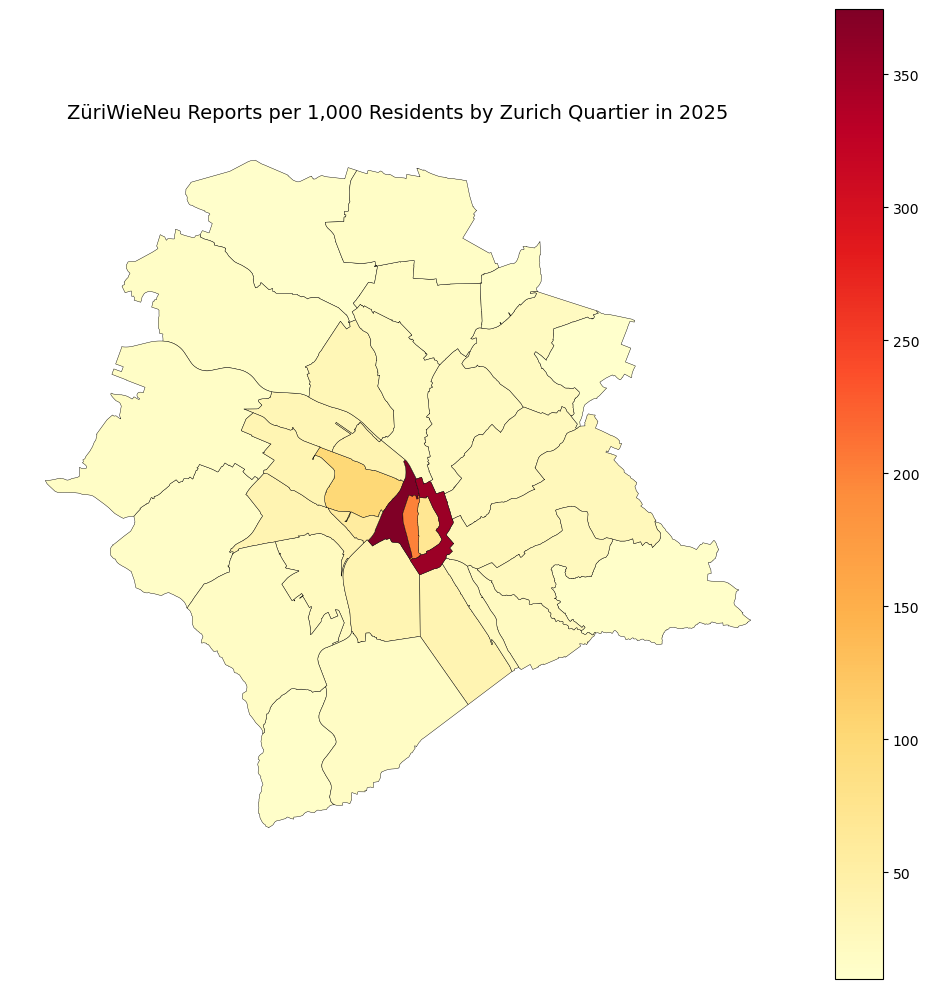

In [40]:
# visualise the reports by population rates
fig, ax = plt.subplots(figsize=(10, 10))

quartiere_rates.plot(
    column="reports_per_1000",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    cmap="YlOrRd",
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    },
)

ax.set_title(
    "ZüriWieNeu Reports per 1,000 Residents by Zurich Quartier in 2025",
    fontsize=14
)

ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../outputs/R3_Choropleth_ReportsPer1000.png",
    bbox_inches="tight"
)
plt.show()

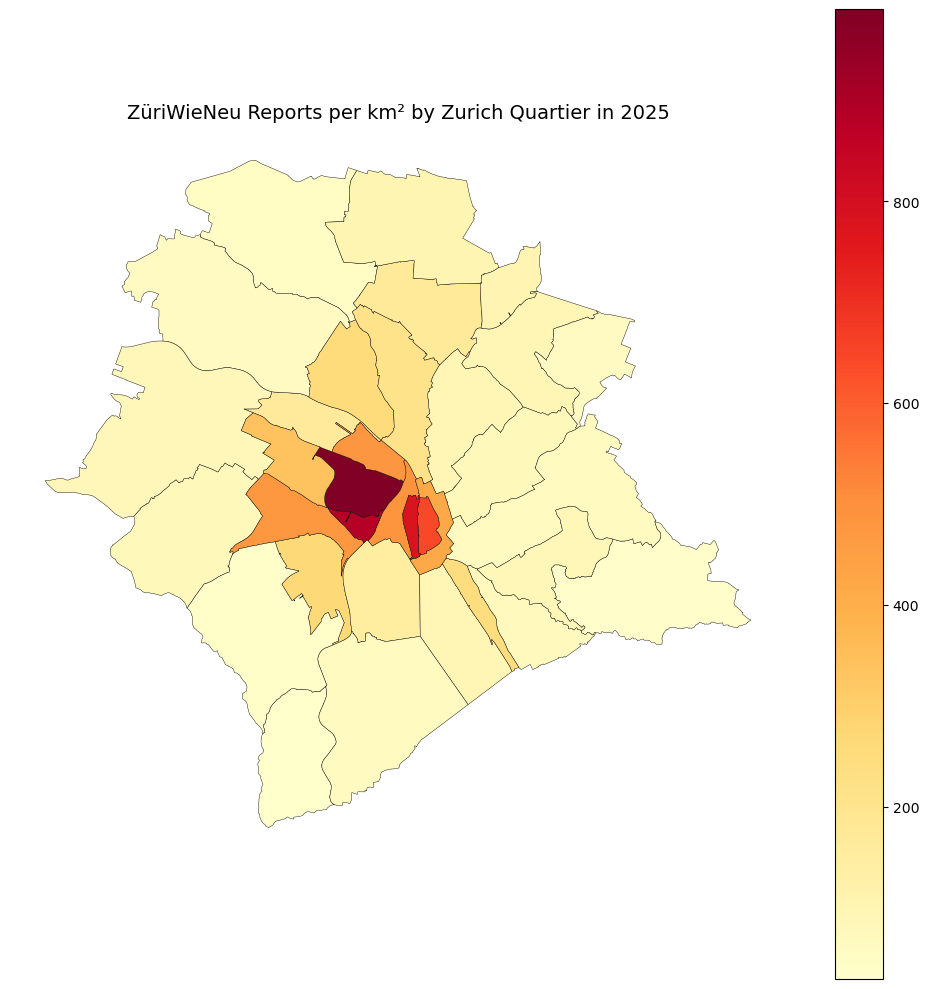

In [41]:
# visualise the reports by Quartier size
fig, ax = plt.subplots(figsize=(10, 10))

quartiere_rates.plot(
    column="reports_per_km2",
    ax=ax,
    legend=True,
    edgecolor="black",
    linewidth=0.3,
    cmap="YlOrRd",
)

ax.set_title(
    "ZüriWieNeu Reports per km² by Zurich Quartier in 2025",
    fontsize=14
)
ax.axis("off")

plt.tight_layout()
plt.savefig(
    "../outputs/R3_Choropleth_ReportsPerKm2.png",
    bbox_inches="tight"
)
plt.show()

<div style="background-color:#eef6ff; padding:15px; border-left:6px solid #4a90e2; border-radius:6px;">

## Comparing the two normalisations: per resident vs. per km²

The two choropleth maps show the same underlying report data normalised in two different ways. Comparing them is more informative than reading either map in isolation, because each one answers a slightly different question and they disagree in a meaningful way.

**Reports per 1,000 residents** measures *reporting intensity relative to the local population*. The map is highly polarised: almost the entire city lies in the lowest colour band, while **City** (374) and **Hochschulen** (353) stand out far above all other Quartiere. This is a direct consequence of how the rate is constructed. Both Quartiere have very small residential populations — **City** has only 769 residents and **Hochschulen** 688 — because they are dominated by offices, shops, museums, and university facilities rather than housing. They receive many reports during the day from visitors, commuters, and students, but only residents appear in the denominator. Dividing a moderate number of reports by a very small resident base produces an inflated per-capita rate that does not really describe the behaviour of the resident population.

**Reports per km²** measures *the spatial density of reports* across the city's surface. The map shows a much more gradual pattern: a clear central peak around Langstrasse, surrounded by a ring of moderately intense Quartiere, and a quieter periphery. Because the denominator is the area of each Quartier rather than its population, this rate is not distorted by the fact that visitors are not counted as residents. It directly captures how densely reports occur on the ground.

The two maps **agree on the overall geographical pattern**: reporting is concentrated in central Zurich and drops off towards the periphery. They also agree that **City** and **Lindenhof** are intense reporting locations under both measures.

The two maps **disagree in an analytically informative way**. **Langstrasse** is the clearest example: it ranks only fourth on the per-resident map (100 reports per 1,000 residents) but first on the per-km² map (almost 990 reports per km²). With 1,200 reports and around 12,000 residents, Langstrasse is a real, large-scale hotspot rather than a small-denominator artefact — and it is the per-km² normalisation that reveals this most clearly. Conversely, **Hochschulen** ranks second per resident but does not stand out per km², because its high per-capita rate comes almost entirely from its small residential base rather than from a high spatial density of reports.

For the research question "where are reports most concentrated?", the **per-km² map is therefore more honest**, because it does not depend on a denominator that excludes the population actually generating most of the reports. The per-resident map remains a useful complementary view, but its extreme values for **City** and **Hochschulen** should be read as an artefact of very small residential populations in non-residential Quartiere, rather than as evidence of unusually active residents.

Two limitations apply to both maps. First, both still describe *reporting activity*, not the actual frequency of urban infrastructure problems. Differences in residents' willingness to use the platform, in the density of reportable infrastructure, and in collection-point locations all shape what is shown. Second, the choropleth resolution is limited by Quartier boundaries: any concentration occurring at the scale of streets or squares is averaged out within each polygon. The Kernel Density Estimation in the next notebook addresses this by working directly with the point locations.
</div>

<div style="background-color:#eef9f0; padding:15px; border-left:6px solid #3c9d5d; border-radius:6px;">

## Conclusion

This notebook analysed the spatial distribution of ZüriWieNeu reports across Zurich's Quartiere in 2025, using two normalised rates rather than absolute counts: reports per 1,000 residents and reports per km².

Each report was converted into a point geometry and spatially joined to the Zurich Quartier polygons. The spatial join was successful for all 2025 reports, meaning that every report could be assigned to a Quartier. Population data per Quartier for 2025 was obtained from Open Data Zürich (*Bevölkerung nach Stadtquartier*), and the Quartier area was computed directly from the shapefile geometry in the Swiss LV95 coordinate system.

The two normalisations gave overlapping but clearly different pictures. Per resident, **City** (374) and **Hochschulen** (353) stand out far above all other Quartiere. Both are central non-residential areas dominated by offices, shops, museums, and university facilities, with very small residential populations of 769 and 688 respectively. Their high per-capita rates therefore reflect a small denominator more than any unusual reporting behaviour by residents. Per km², the strongest hotspot is **Langstrasse** with almost 990 reports per km², followed by **Lindenhof**, **Rathaus**, and **City**. Langstrasse illustrates the difference between the two measures most clearly: it ranks only fourth on the per-resident map (100 reports per 1,000 residents) but first on the per-km² map, because its 1,200 reports are concentrated in a small area while still being distributed across a larger residential base of around 12,000 people.

For the research question of where reports are most concentrated in Zurich, the per-km² rate provides the more robust answer, because it does not depend on a denominator that excludes the visitors and commuters who generate many of the reports in central Quartiere. The per-resident rate remains a useful complementary measure, but its extremes should be interpreted with caution.

These results should still be read as **patterns of reporting activity** rather than direct measurements of urban infrastructure quality. Differences in residents' willingness to use the ZüriWieNeu platform, in the density of reportable infrastructure, and in the presence of waste-collection points and nightlife also shape the patterns shown here. The choropleth analysis is also limited by Quartier boundaries: any concentration that occurs at the scale of individual streets or squares is averaged out within each polygon. The Kernel Density Estimation in the next notebook addresses this by working directly with the point locations, complementing the Quartier-level view developed here.
</div>